# AHEAD Synthetic Patients — Population Overview

**Goal:** Understand *who* the patients are, what a typical patient looks like, and which tests are performed on ≥ 90 % of the cohort (i.e. the de-facto standard-of-care panel).

---

| Section | Question answered |
|---|---|
| 1. Setup & data load | Shared infrastructure |
| 2. Cohort snapshot | How many patients, gender split, age profile |
| 3. "Average patient" card | Median demographics + most common severity profile |
| 4. Health profile summary | Severity breakdown across organs and data sources |
| 5. Standard-of-care panel | Biomarkers measured in ≥ 90 % of patients |


## 1. Setup & Data Load


In [9]:
import json, os, glob
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)
sns.set_theme(style="whitegrid")
%matplotlib inline

# ── paths ─────────────────────────────────────────────────────────────────────
DATA_DIR = r"C:\Users\ABCLe\Downloads\synthetic_patient_datasets 2\ahead_synthetic_data"

QUESTIONNAIRE_KEYS = {
    "0cfa9d7e-a9ac-491a-bffe-00c928b420b2",
    "8c0529a5-c943-4557-857f-ec2f93c309a1",
}

def normalise_fgk(key):
    return "patient_questionnaire" if key in QUESTIONNAIRE_KEYS else key

def ts_to_dt(ts):
    if isinstance(ts, dict) and "_seconds" in ts:
        return datetime.utcfromtimestamp(ts["_seconds"])
    return None

def flatten_dp(report_key, patient, dp):
    bio  = (dp.get("dataPoint") or {}).get("biomarkerData") or {}
    tags = (dp.get("dataPoint") or {}).get("tags") or {}
    asmt = (dp.get("dataPoint") or {}).get("assessment") or {}
    return {
        "report_key":     report_key,
        "patient_key":    patient.get("patientKey"),
        "patient_gender": patient.get("patientGender"),
        "patient_age":    patient.get("patientAge"),
        "file_group_key": normalise_fgk(dp.get("fileGroupKey")),
        "archived":       dp.get("archived"),
        "severity":       asmt.get("severity"),
        "organ":          tags.get("organ"),
        "source":         tags.get("source"),
        "info_type":      tags.get("infoType"),
        "biomarker_id":   bio.get("biomarkerId"),
        "biomarker_name": bio.get("biomarkerNameFromSource"),
        "value":          bio.get("value"),
        "collected_on":   ts_to_dt((dp.get("dataPoint") or {}).get("collectedOnDate")),
    }

json_files = [f for f in glob.glob(os.path.join(DATA_DIR, "*.json"))
              if " copy" not in os.path.basename(f)]

patient_rows, dp_rows = [], []
for path in json_files:
    rk = os.path.splitext(os.path.basename(path))[0]
    with open(path, encoding="utf-8") as f:
        data = json.load(f)
    for pt in data.get("patients", []):
        patient_rows.append({
            "report_key":       rk,
            "patient_key":      pt.get("patientKey"),
            "patient_gender":   pt.get("patientGender"),
            "patient_age":      pt.get("patientAge"),
            "patient_birthday": pt.get("patientBirthday"),
            "datapoint_count":  pt.get("datapointCount"),
            "exported_at":      data.get("exportedAt"),
        })
        for dp in pt.get("datapoints", []):
            dp_rows.append(flatten_dp(rk, pt, dp))

df_patients = pd.DataFrame(patient_rows)
df_dp       = pd.DataFrame(dp_rows)

df_patients["patient_birthday"] = pd.to_datetime(df_patients["patient_birthday"], errors="coerce")
df_patients["exported_at"]      = pd.to_datetime(df_patients["exported_at"], errors="coerce")
df_dp["value"]                  = pd.to_numeric(df_dp["value"], errors="coerce")
df_dp["collected_on"]           = pd.to_datetime(df_dp["collected_on"], errors="coerce")

# one row per unique patient (latest report wins if a patient appears in >1 file)
unique_pts = (df_patients.sort_values("exported_at")
                         .drop_duplicates("patient_key", keep="last"))

N = unique_pts["patient_key"].nunique()
print(f"✓  {len(json_files)} JSON files loaded")
print(f"✓  {N} unique patients  |  {len(df_dp):,} datapoints")


✓  62 JSON files loaded
✓  62 unique patients  |  8,421 datapoints


## 2. Cohort Snapshot

Basic counts and demographic breakdown of the patient population.


C:\Users\ABCLe\AppData\Local\Temp\ipykernel_24688\4156779581.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


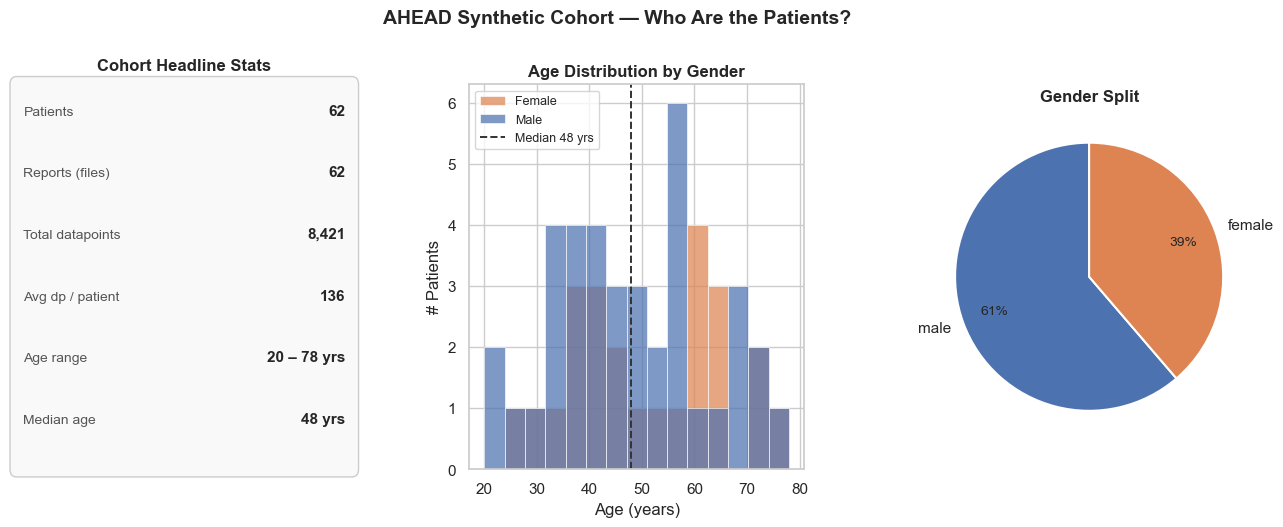


Age statistics:


,patient_age
count,62.000000
mean,49.274194
std,14.563788
min,20.000000
25%,38.250000
50%,48.000000
75%,59.750000
max,78.000000



Gender counts:


,count
patient_gender,
male,38
female,24


In [10]:
# ── Cohort top-line numbers ────────────────────────────────────────────────────
age  = unique_pts["patient_age"].dropna()
gend = unique_pts["patient_gender"].str.lower().value_counts()

GENDER_COLORS = {"male": "#4C72B0", "female": "#DD8452", "other": "#55A868"}

fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# ── panel 1: cohort headline stats ────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0])
ax0.axis("off")
stats = [
    ("Patients",          f"{N}"),
    ("Reports (files)",   f"{len(json_files)}"),
    ("Total datapoints",  f"{len(df_dp):,}"),
    ("Avg dp / patient",  f"{len(df_dp)/N:.0f}"),
    ("Age range",         f"{age.min():.0f} – {age.max():.0f} yrs"),
    ("Median age",        f"{age.median():.0f} yrs"),
]
for i, (label, value) in enumerate(stats):
    ax0.text(0.02, 0.92 - i * 0.16, label, fontsize=10, color="#555", transform=ax0.transAxes)
    ax0.text(0.98, 0.92 - i * 0.16, value, fontsize=11, fontweight="bold",
             ha="right", transform=ax0.transAxes)
ax0.set_title("Cohort Headline Stats", fontsize=12, fontweight="bold", pad=10)
ax0.add_patch(mpatches.FancyBboxPatch((0, 0), 1, 1, boxstyle="round,pad=0.02",
              linewidth=1, edgecolor="#ccc", facecolor="#f9f9f9",
              transform=ax0.transAxes, clip_on=False))

# ── panel 2: age histogram by gender ──────────────────────────────────────────
ax1 = fig.add_subplot(gs[1])
bins = np.linspace(age.min(), age.max(), 16)
pts_with_age = unique_pts.dropna(subset=["patient_age", "patient_gender"]).copy()
pts_with_age["patient_gender"] = pts_with_age["patient_gender"].str.lower()
for gender, grp in pts_with_age.groupby("patient_gender"):
    ax1.hist(grp["patient_age"], bins=bins, alpha=0.72, edgecolor="white", linewidth=0.6,
             color=GENDER_COLORS.get(gender, "#888"), label=gender.capitalize())
ax1.axvline(age.median(), color="#333", linestyle="--", linewidth=1.4,
            label=f"Median {age.median():.0f} yrs")
ax1.set_title("Age Distribution by Gender", fontsize=12, fontweight="bold")
ax1.set_xlabel("Age (years)")
ax1.set_ylabel("# Patients")
ax1.legend(fontsize=9)

# ── panel 3: gender pie ────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[2])
colors_pie = [GENDER_COLORS.get(g, "#888") for g in gend.index]
wedges, texts, autotexts = ax2.pie(
    gend.values, labels=gend.index,
    colors=colors_pie, autopct="%1.0f%%",
    startangle=90, pctdistance=0.75,
    wedgeprops=dict(edgecolor="white", linewidth=1.5)
)
for t in autotexts:
    t.set_fontsize(10)
ax2.set_title("Gender Split", fontsize=12, fontweight="bold")

plt.suptitle("AHEAD Synthetic Cohort — Who Are the Patients?", fontsize=14,
             fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

# Numeric summary table
print("\nAge statistics:")
display(age.describe().rename("patient_age").to_frame())
print("\nGender counts:")
display(gend.rename("count").to_frame())


## 3. The "Average Patient" Card

What does a representative patient in this cohort look like?  
We combine median demographics with the modal severity profile.


╔════════════════════════════════════════════════════════════╗
║                  THE AVERAGE AHEAD PATIENT                 ║
╠════════════════════════════════════════════════════════════╣
║  Age                 : 48 years (median)                  ║
║  Gender (mode)       : Male                                 ║
║  Datapoints / visit  : 128 measurements (median)              ║
║  Primary data group  : lab_results                          ║
╠════════════════════════════════════════════════════════════╣
║            Most flagged results (Bad / Critical)           ║
╠────────────────────────────────────────────────────────────╣
║  🩸 Blood (lab)         : Albumin                              ║
║     organ              : Digestive03                          ║
║     # patients flagged : 35 / 62                                ║
╠────────────────────────────────────────────────────────────╣
║  🧠 Image biomarker     : Parietallappen GS rechts             ║
║     organ              : Nervous05 

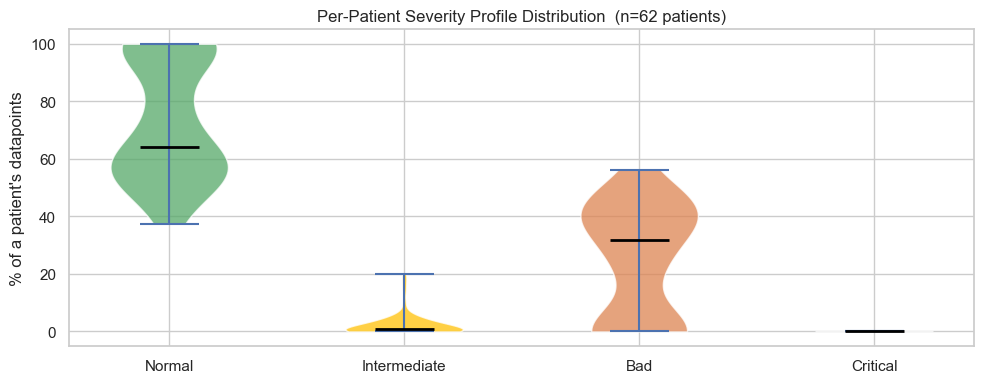

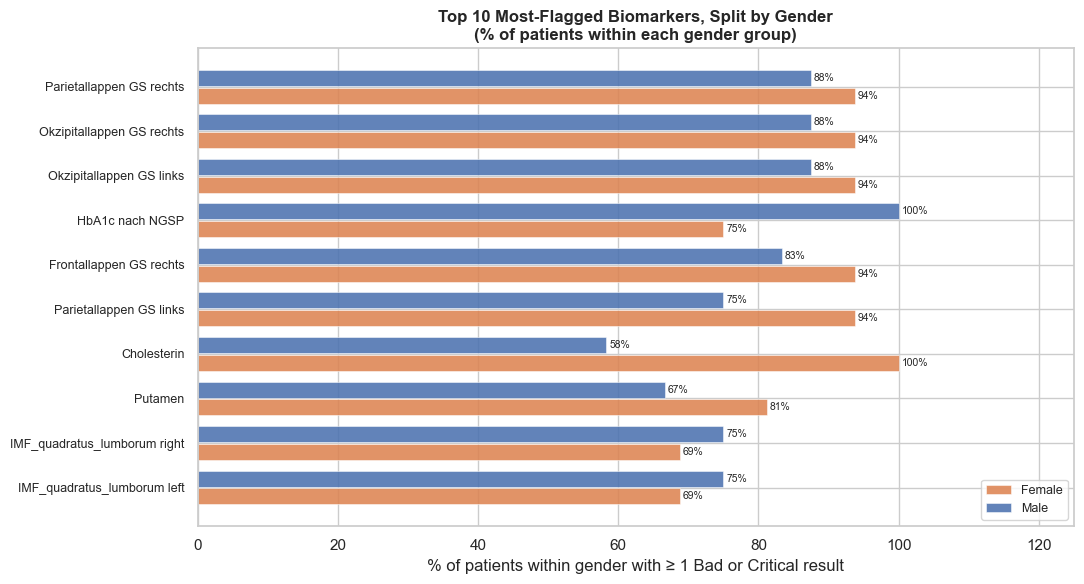

In [12]:

# ── Per-patient severity profile ──────────────────────────────────────────────
SEV_ORDER  = ["Normal", "Intermediate", "Bad", "Critical"]
SEV_COLORS = {"Normal": "#55A868", "Intermediate": "#FFC107",
              "Bad": "#DD8452", "Critical": "#C44E52"}

# Count severity labels per patient, then compute cohort-level stats
sev_per_pt = (
    df_dp[df_dp["severity"].notna()]
    .groupby(["patient_key", "severity"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=SEV_ORDER, fill_value=0)
)
sev_pct_per_pt = sev_per_pt.div(sev_per_pt.sum(axis=1), axis=0) * 100

# Modal gender  (df_dp already carries patient_gender from flatten_dp)
modal_gender = df_dp["patient_gender"].str.lower().mode()[0]

# Most common source mix
modal_source = df_dp["source"].value_counts().idxmax()
modal_fgk    = (df_dp[df_dp["file_group_key"] != "patient_questionnaire"]
                ["file_group_key"].value_counts().idxmax())

# Most flagged organ overall (Bad/Critical), broken down by source
flagged = df_dp[df_dp["severity"].isin(["Bad", "Critical"])].copy()
flagged["patient_gender"] = flagged["patient_gender"].str.lower().str.strip().fillna("unknown")

def top_flagged(source_filter=None):
    """Return (organ, biomarker_name, source, n_patients) for the most-flagged biomarker."""
    sub = flagged.copy()
    if source_filter:
        sub = sub[sub["source"] == source_filter]
    if sub.empty:
        return ("—", "—", "—", 0)
    top_organ = sub["organ"].value_counts().idxmax()
    organ_sub = sub[sub["organ"] == top_organ]
    top_bio   = organ_sub["biomarker_name"].value_counts().idxmax() if organ_sub["biomarker_name"].notna().any() else "—"
    top_src   = organ_sub["source"].mode()[0] if organ_sub["source"].notna().any() else "—"
    n_pts     = organ_sub["patient_key"].nunique()
    return (top_organ, top_bio, top_src, n_pts)

overall_organ, overall_bio, overall_src, overall_n = top_flagged()
blood_organ,   blood_bio,   blood_src,   blood_n   = top_flagged("Blood")
image_organ,   image_bio,   image_src,   image_n   = top_flagged("ImageBiomarker")

# ── Print "patient card" ───────────────────────────────────────────────────────
median_dp = df_dp.groupby("patient_key").size().median()

W = 60  # box width
print("╔" + "═"*W + "╗")
print("║" + "  THE AVERAGE AHEAD PATIENT".center(W) + "║")
print("╠" + "═"*W + "╣")
print(f"║  {'Age':<20}: {age.median():.0f} years (median){'':<18}║")
print(f"║  {'Gender (mode)':<20}: {modal_gender.capitalize():<37}║")
print(f"║  {'Datapoints / visit':<20}: {median_dp:.0f} measurements (median){'':<14}║")
print(f"║  {'Primary data group':<20}: {modal_fgk:<37}║")
print("╠" + "═"*W + "╣")
print("║" + "  Most flagged results (Bad / Critical)".center(W) + "║")
print("╠" + "─"*W + "╣")
print(f"║  {'🩸 Blood (lab)':<22}: {blood_bio or blood_organ:<37}║")
print(f"║  {'   organ':<22}: {blood_organ:<37}║")
print(f"║  {'   # patients flagged':<22}: {blood_n} / {N}{'':<32}║")
print("╠" + "─"*W + "╣")
print(f"║  {'🧠 Image biomarker':<22}: {image_bio or image_organ:<37}║")
print(f"║  {'   organ':<22}: {image_organ:<37}║")
print(f"║  {'   # patients flagged':<22}: {image_n} / {N}{'':<32}║")
print("╠" + "═"*W + "╣")
print("║" + "  Severity profile (median % of measurements)".center(W) + "║")
for sev in SEV_ORDER:
    if sev in sev_pct_per_pt.columns:
        med_pct = sev_pct_per_pt[sev].median()
        bar = "█" * int(med_pct / 3)
        print(f"║    {sev:<16}: {med_pct:5.1f}%  {bar:<20}     ║")
print("╚" + "═"*W + "╝")

# ── Violin: per-patient % in each severity bucket ─────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
data_plot = [sev_pct_per_pt[s].values for s in SEV_ORDER if s in sev_pct_per_pt.columns]
colors_v  = [SEV_COLORS[s] for s in SEV_ORDER if s in sev_pct_per_pt.columns]
labels_v  = [s for s in SEV_ORDER if s in sev_pct_per_pt.columns]

vp = ax.violinplot(data_plot, positions=range(len(labels_v)), showmedians=True, showextrema=True)
for body, col in zip(vp["bodies"], colors_v):
    body.set_facecolor(col)
    body.set_alpha(0.75)
vp["cmedians"].set_color("black")
vp["cmedians"].set_linewidth(2)

ax.set_xticks(range(len(labels_v)))
ax.set_xticklabels(labels_v, fontsize=11)
ax.set_ylabel("% of a patient's datapoints")
ax.set_title(f"Per-Patient Severity Profile Distribution  (n={N} patients)", fontsize=12)
plt.tight_layout()
plt.show()

# ── Bar: top 10 most-flagged biomarkers, split by gender ──────────────────────
SOURCE_COLORS = {"Blood": "#4C72B0", "ImageBiomarker": "#DD8452",
                 "Urine": "#55A868", "Unknown": "#888888"}
GENDER_COLORS = {"male": "#4C72B0", "female": "#DD8452", "unknown": "#888888", "other": "#55A868"}

# flagged already has patient_gender from df_dp
# Patients per gender (denominator for rate)
pts_per_gender = (
    flagged.drop_duplicates("patient_key")
    .groupby("patient_gender")["patient_key"].nunique()
)

# Top 10 biomarkers by overall flagged patient count
top10_bio = (
    flagged.dropna(subset=["biomarker_name"])
    .groupby(["biomarker_name", "source"])["patient_key"]
    .nunique()
    .reset_index(name="n_patients_flagged")
    .sort_values("n_patients_flagged", ascending=False)
    .drop_duplicates("biomarker_name")
    .head(10)["biomarker_name"]
    .tolist()
)

# Count flagged patients per biomarker × gender
bio_gender = (
    flagged[flagged["biomarker_name"].isin(top10_bio)]
    .dropna(subset=["biomarker_name"])
    .groupby(["biomarker_name", "patient_gender"])["patient_key"]
    .nunique()
    .reset_index(name="n_flagged")
)
bio_gender["pct"] = bio_gender.apply(
    lambda r: r["n_flagged"] / pts_per_gender.get(r["patient_gender"], N) * 100, axis=1
).round(1)

bio_pivot = (
    bio_gender.pivot(index="biomarker_name", columns="patient_gender", values="pct")
    .reindex(top10_bio)
    .fillna(0)
)
# Sort by overall flag count (ascending for horizontal bar)
overall_count = (
    flagged[flagged["biomarker_name"].isin(top10_bio)]
    .dropna(subset=["biomarker_name"])
    .groupby("biomarker_name")["patient_key"].nunique()
)
bio_pivot = bio_pivot.loc[overall_count.sort_values().index]

genders_g = bio_pivot.columns.tolist()
n_bio     = len(bio_pivot)
bar_h     = 0.8 / max(len(genders_g), 1)
y_pos     = np.arange(n_bio)

fig, ax = plt.subplots(figsize=(11, 6))
for i, gender in enumerate(genders_g):
    offset = (i - (len(genders_g) - 1) / 2) * bar_h
    bars = ax.barh(
        y_pos + offset,
        bio_pivot[gender].values,
        height=bar_h * 0.9,
        color=GENDER_COLORS.get(gender, "#888"),
        label=gender.capitalize(),
        edgecolor="white", linewidth=0.4, alpha=0.88
    )
    ax.bar_label(bars, fmt="%.0f%%", padding=2, fontsize=7.5)

ax.set_yticks(y_pos)
ax.set_yticklabels(bio_pivot.index, fontsize=9)
ax.set_xlabel("% of patients within gender with ≥ 1 Bad or Critical result")
ax.set_title("Top 10 Most-Flagged Biomarkers, Split by Gender\n(% of patients within each gender group)",
             fontsize=12, fontweight="bold")
ax.set_xlim(0, max(bio_pivot.values.max() * 1.25, 20))
ax.legend(fontsize=9, loc="lower right")
plt.tight_layout()
plt.show()


## 4. Health Profile Summary

How does severity distribute across **organs** and **data sources**?  
This reveals where abnormal results cluster and which measurement types drive the most flags.


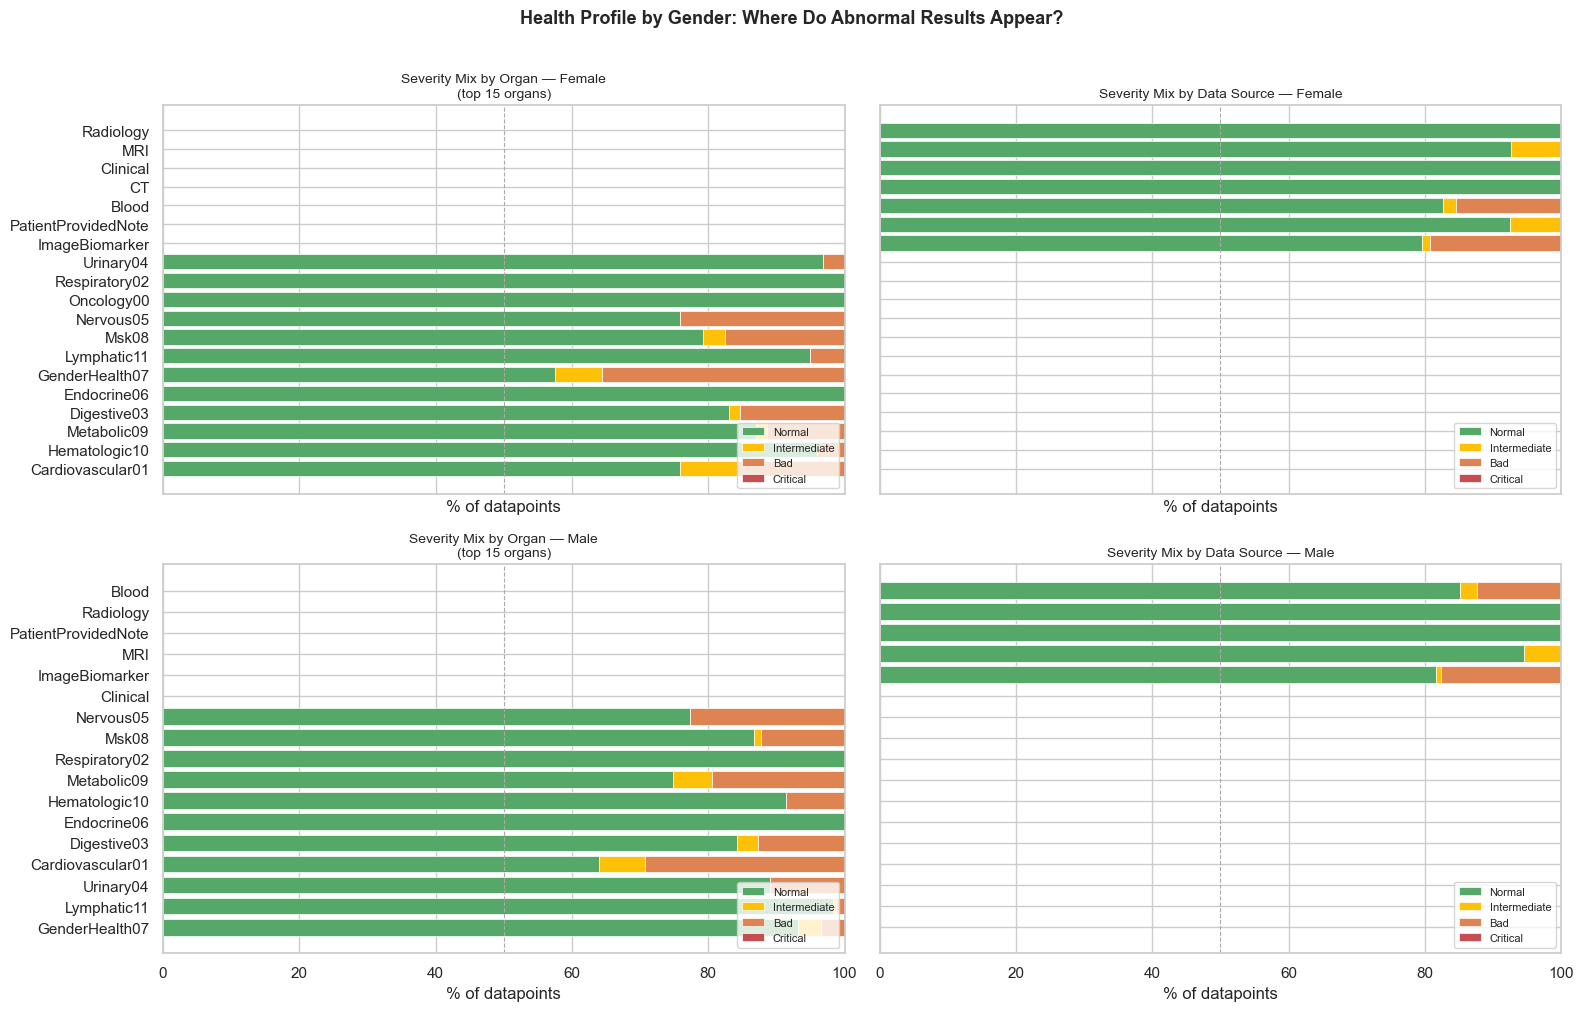

In [13]:

# ── 4a. Severity mix by organ, split by gender ─────────────────────────────────
top_organs = df_dp["organ"].value_counts().head(15).index.tolist()

# df_dp already has patient_gender from flatten_dp — just normalise it
df_dp_g = df_dp.copy()
df_dp_g["patient_gender"] = df_dp_g["patient_gender"].str.lower().str.strip().fillna("unknown")
genders_present = sorted(df_dp_g["patient_gender"].unique())

fig, axes = plt.subplots(len(genders_present), 2,
                         figsize=(16, 5 * len(genders_present)),
                         sharex="col", sharey="row")
# Ensure axes is always 2-D
if len(genders_present) == 1:
    axes = [axes]

for row_idx, gender in enumerate(genders_present):
    sub = df_dp_g[(df_dp_g["organ"].isin(top_organs)) &
                  df_dp_g["severity"].notna() &
                  (df_dp_g["patient_gender"] == gender)]

    # ── Left: Severity mix by organ ──────────────────────────────────────────
    organ_sev = (
        sub.groupby(["organ", "severity"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=SEV_ORDER, fill_value=0)
    )
    organ_sev_pct = organ_sev.div(organ_sev.sum(axis=1), axis=0) * 100
    organ_sev_pct = organ_sev_pct.loc[organ_sev_pct.sum(axis=1).sort_values().index]

    left_arr = np.zeros(len(organ_sev_pct))
    for sev in SEV_ORDER:
        if sev in organ_sev_pct.columns:
            vals = organ_sev_pct[sev].values
            axes[row_idx][0].barh(organ_sev_pct.index, vals, left=left_arr,
                                  color=SEV_COLORS[sev], label=sev,
                                  edgecolor="white", linewidth=0.5)
            left_arr += vals
    axes[row_idx][0].set_xlabel("% of datapoints")
    axes[row_idx][0].set_title(
        f"Severity Mix by Organ — {gender.capitalize()}\n(top 15 organs)", fontsize=10)
    axes[row_idx][0].legend(loc="lower right", fontsize=8)
    axes[row_idx][0].axvline(50, color="#aaa", linestyle="--", linewidth=0.8)

    # ── Right: Severity mix by data source ───────────────────────────────────
    source_sev = (
        sub[sub["source"].notna()]
        .groupby(["source", "severity"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=SEV_ORDER, fill_value=0)
    )
    source_sev_pct = source_sev.div(source_sev.sum(axis=1), axis=0) * 100
    source_sev_pct = source_sev_pct.loc[source_sev_pct.sum(axis=1).sort_values().index]

    left2 = np.zeros(len(source_sev_pct))
    for sev in SEV_ORDER:
        if sev in source_sev_pct.columns:
            vals = source_sev_pct[sev].values
            axes[row_idx][1].barh(source_sev_pct.index, vals, left=left2,
                                  color=SEV_COLORS[sev], label=sev,
                                  edgecolor="white", linewidth=0.5)
            left2 += vals
    axes[row_idx][1].set_xlabel("% of datapoints")
    axes[row_idx][1].set_title(
        f"Severity Mix by Data Source — {gender.capitalize()}", fontsize=10)
    axes[row_idx][1].legend(loc="lower right", fontsize=8)
    axes[row_idx][1].axvline(50, color="#aaa", linestyle="--", linewidth=0.8)

plt.suptitle("Health Profile by Gender: Where Do Abnormal Results Appear?",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


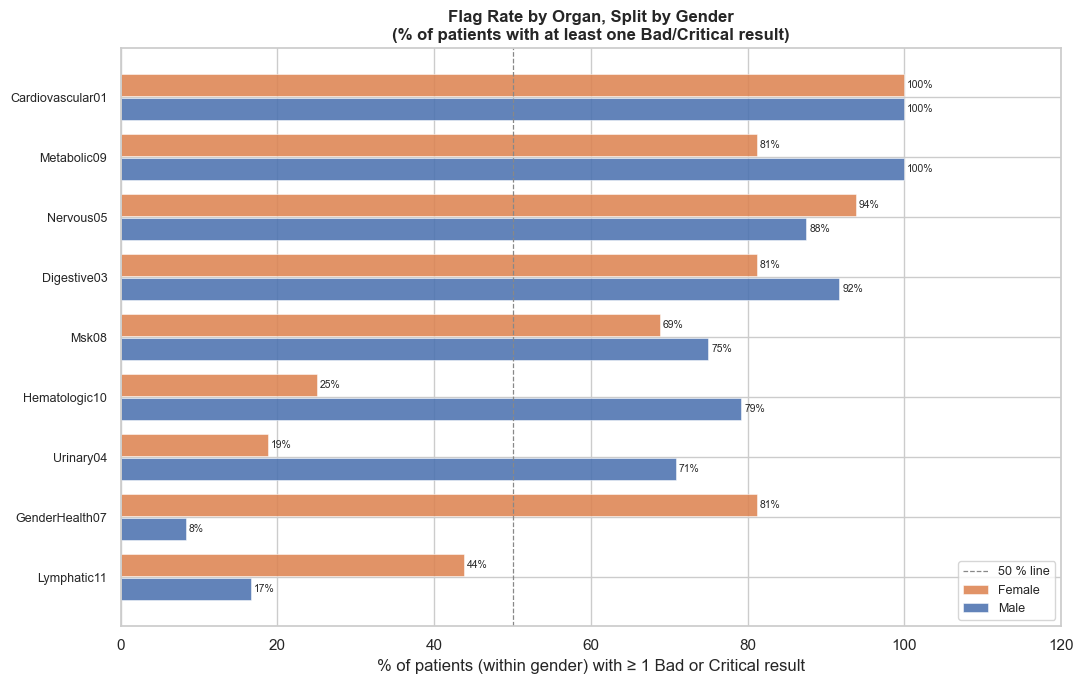

In [14]:

# ── 4c. Flag-rate by organ, split by gender ────────────────────────────────────
# df_dp already has patient_gender from flatten_dp — just normalise it
flagged_dp = df_dp[df_dp["severity"].isin(["Bad", "Critical"]) & df_dp["organ"].notna()].copy()
flagged_dp["patient_gender"] = flagged_dp["patient_gender"].str.lower().str.strip().fillna("unknown")

# Patients per gender (denominator) — from unique patients in flagged data
pts_by_gender = (
    flagged_dp.drop_duplicates("patient_key")
    .groupby("patient_gender")["patient_key"].nunique()
)

# Top 20 organs by overall flag rate (for ordering)
top20_organs = (
    flagged_dp.groupby("organ")["patient_key"]
    .nunique()
    .div(N)
    .sort_values(ascending=False)
    .head(20)
    .index.tolist()
)

# Flag rate per organ × gender
flag_by_gender = (
    flagged_dp[flagged_dp["organ"].isin(top20_organs)]
    .groupby(["organ", "patient_gender"])["patient_key"]
    .nunique()
    .reset_index(name="n_flagged")
)
flag_by_gender["pct"] = flag_by_gender.apply(
    lambda r: r["n_flagged"] / pts_by_gender.get(r["patient_gender"], N) * 100, axis=1
).round(1)

# Pivot so each gender is a column
flag_pivot = (
    flag_by_gender.pivot(index="organ", columns="patient_gender", values="pct")
    .reindex(top20_organs)
    .fillna(0)
)

# ── Plot ───────────────────────────────────────────────────────────────────────
GENDER_COLORS = {"male": "#4C72B0", "female": "#DD8452", "unknown": "#888888", "other": "#55A868"}
genders = flag_pivot.columns.tolist()

n_organs = len(flag_pivot)
bar_h    = 0.8 / max(len(genders), 1)
y_pos    = np.arange(n_organs)

fig, ax = plt.subplots(figsize=(11, 7))
for i, gender in enumerate(genders):
    offset = (i - (len(genders) - 1) / 2) * bar_h
    bars = ax.barh(
        y_pos + offset,
        flag_pivot[gender].values,
        height=bar_h * 0.9,
        color=GENDER_COLORS.get(gender, "#888"),
        label=gender.capitalize(),
        edgecolor="white", linewidth=0.4, alpha=0.88
    )
    ax.bar_label(bars, fmt="%.0f%%", padding=2, fontsize=7.5)

ax.set_yticks(y_pos)
ax.set_yticklabels(flag_pivot.index, fontsize=9)
ax.invert_yaxis()
ax.axvline(50, color="#888", linestyle="--", linewidth=0.9, label="50 % line")
ax.set_xlabel("% of patients (within gender) with ≥ 1 Bad or Critical result")
ax.set_title("Flag Rate by Organ, Split by Gender\n(% of patients with at least one Bad/Critical result)",
             fontsize=12, fontweight="bold")
ax.set_xlim(0, 120)
ax.legend(fontsize=9, loc="lower right")
plt.tight_layout()
plt.show()


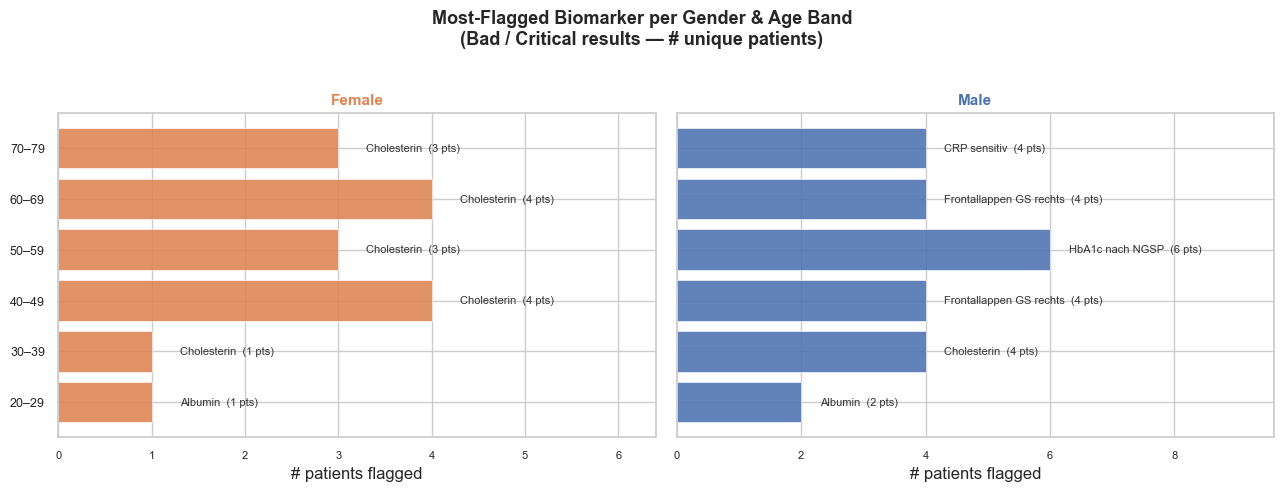

In [15]:

# ── 4d. Most-flagged biomarker per gender × age band ──────────────────────────
# Build a working frame: flagged datapoints with age + gender attached
# df_dp carries patient_gender; patient_age comes from unique_pts
age_map = unique_pts.set_index("patient_key")["patient_age"]

flagged_age = df_dp[df_dp["severity"].isin(["Bad", "Critical"])].copy()
flagged_age["patient_gender"] = (flagged_age["patient_gender"]
                                  .str.lower().str.strip().fillna("unknown"))
flagged_age["patient_age_val"] = flagged_age["patient_key"].map(age_map)
flagged_age = flagged_age.dropna(subset=["patient_age_val", "biomarker_name"])

# 10-year age bins
age_min = int(flagged_age["patient_age_val"].min() // 10 * 10)
age_max = int(flagged_age["patient_age_val"].max() // 10 * 10) + 10
bin_edges  = list(range(age_min, age_max + 10, 10))
bin_labels = [f"{lo}–{lo+9}" for lo in bin_edges[:-1]]

flagged_age["age_band"] = pd.cut(
    flagged_age["patient_age_val"],
    bins=bin_edges, labels=bin_labels, right=False
)
flagged_age = flagged_age.dropna(subset=["age_band"])

# For each (gender, age_band) find the biomarker with the most unique patients flagged
def top_bio_for_group(grp):
    counts = grp.groupby("biomarker_name")["patient_key"].nunique()
    if counts.empty:
        return pd.Series({"top_biomarker": "—", "n_patients": 0})
    return pd.Series({"top_biomarker": counts.idxmax(), "n_patients": int(counts.max())})

summary = (
    flagged_age.groupby(["patient_gender", "age_band"], observed=True)
    .apply(top_bio_for_group)
    .reset_index()
)

genders_plot = [g for g in ["female", "male", "other", "unknown"]
                if g in summary["patient_gender"].unique()]

fig, axes = plt.subplots(
    1, len(genders_plot),
    figsize=(6.5 * len(genders_plot), max(4, len(bin_labels) * 0.55 + 1.5)),
    sharey=True
)
if len(genders_plot) == 1:
    axes = [axes]

GENDER_PALETTE = {"male": "#4C72B0", "female": "#DD8452",
                  "unknown": "#888888", "other": "#55A868"}

for ax, gender in zip(axes, genders_plot):
    sub = (summary[summary["patient_gender"] == gender]
           .set_index("age_band")
           .reindex(bin_labels))          # keep age bands in order

    n_vals     = sub["n_patients"].fillna(0).astype(int).values
    bio_labels = sub["top_biomarker"].fillna("—").values
    y          = np.arange(len(bin_labels))

    base_color = GENDER_PALETTE.get(gender, "#888")
    bar_colors = [base_color if b != "—" else "#dddddd" for b in bio_labels]

    bars = ax.barh(y, n_vals, color=bar_colors,
                   edgecolor="white", linewidth=0.5, alpha=0.88)

    # Annotate each bar with the biomarker name + patient count
    for yi, (n, bio) in enumerate(zip(n_vals, bio_labels)):
        if bio != "—" and n > 0:
            ax.text(n + max(n_vals.max() * 0.01, 0.3), yi,
                    f"{bio}  ({n} pts)", va="center", fontsize=8,
                    color="#333")

    ax.set_yticks(y)
    ax.set_yticklabels(bin_labels, fontsize=9)
    ax.set_xlabel("# patients flagged")
    ax.set_title(f"{gender.capitalize()}", fontsize=11, fontweight="bold",
                 color=base_color)
    ax.set_xlim(0, max(n_vals.max() * 1.6, 5))
    ax.invert_yaxis()
    ax.tick_params(axis="x", labelsize=8)

fig.suptitle(
    "Most-Flagged Biomarker per Gender & Age Band\n"
    "(Bad / Critical results — # unique patients)",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.show()


## 5. Standard-of-Care Panel

Which biomarkers are measured for **≥ 90 % of patients**?  
These represent the tests that are universally ordered — the de-facto standard-of-care protocol in this dataset.


In [8]:
# ── 5a. Biomarker patient coverage ────────────────────────────────────────────
THRESHOLD = 90   # % of patients

bio_coverage = (
    df_dp.dropna(subset=["biomarker_id", "patient_key", "biomarker_name"])
    .groupby(["biomarker_id", "biomarker_name"])["patient_key"]
    .nunique()
    .reset_index(name="n_patients")
)
bio_coverage["pct_patients"] = (bio_coverage["n_patients"] / N * 100).round(1)

# Deduplicate names that share the same biomarker_name (% vs abs. ambiguity)
# Keep the row with higher coverage for display clarity
bio_coverage_dedup = (bio_coverage.sort_values("pct_patients", ascending=False)
                                   .drop_duplicates("biomarker_name", keep="first"))

soc_panel = bio_coverage_dedup[bio_coverage_dedup["pct_patients"] >= THRESHOLD].copy()
soc_panel = soc_panel.sort_values("pct_patients", ascending=True).reset_index(drop=True)

print(f"Biomarkers measured in ≥ {THRESHOLD}% of patients: {len(soc_panel)}")


Biomarkers measured in ≥ 90% of patients: 19


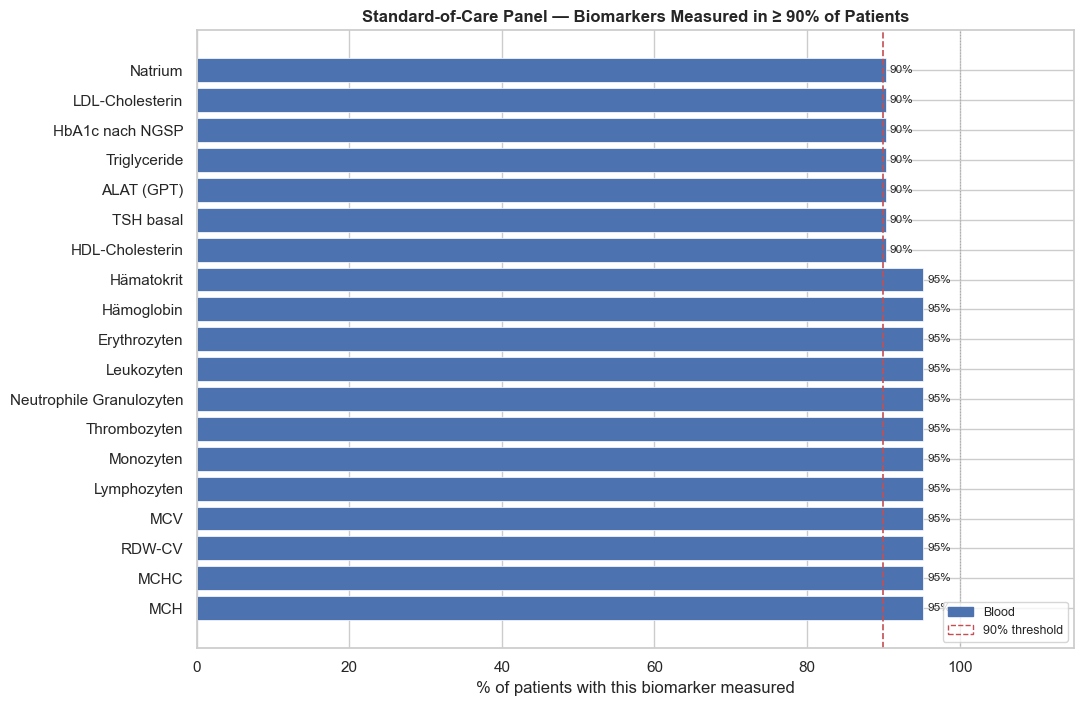

In [9]:
# ── 5b. Visualise the SoC panel ───────────────────────────────────────────────

# Enrich with organ & source (take modal value per biomarker_id)
organ_map  = (df_dp.dropna(subset=["biomarker_id","organ"])
              .groupby("biomarker_id")["organ"].agg(lambda x: x.mode()[0]))
source_map = (df_dp.dropna(subset=["biomarker_id","source"])
              .groupby("biomarker_id")["source"].agg(lambda x: x.mode()[0]))

soc_panel["organ"]  = soc_panel["biomarker_id"].map(organ_map).fillna("Unknown")
soc_panel["source"] = soc_panel["biomarker_id"].map(source_map).fillna("Unknown")

# Assign colour by source
SOURCE_COLORS = {"Blood": "#4C72B0", "ImageBiomarker": "#DD8452",
                 "Urine": "#55A868", "Unknown": "#888888"}
bar_colors = [SOURCE_COLORS.get(s, "#888") for s in soc_panel["source"]]

fig, ax = plt.subplots(figsize=(11, max(5, len(soc_panel) * 0.38)))
bars = ax.barh(soc_panel["biomarker_name"], soc_panel["pct_patients"],
               color=bar_colors, edgecolor="white", linewidth=0.5)
ax.bar_label(bars, fmt="%.0f%%", padding=3, fontsize=8.5)
ax.axvline(THRESHOLD, color="#C44E52", linestyle="--", linewidth=1.2,
           label=f"{THRESHOLD}% threshold")
ax.axvline(100, color="#aaa", linestyle=":", linewidth=0.8)
ax.set_xlim(0, 115)
ax.set_xlabel("% of patients with this biomarker measured")
ax.set_title(f"Standard-of-Care Panel — Biomarkers Measured in ≥ {THRESHOLD}% of Patients",
             fontsize=12, fontweight="bold")
ax.invert_yaxis()

# Legend for source colours
legend_patches = [mpatches.Patch(color=c, label=s) for s, c in SOURCE_COLORS.items()
                  if s in soc_panel["source"].values]
legend_patches.append(mpatches.Patch(color="#C44E52", label=f"{THRESHOLD}% threshold",
                                     linestyle="--", fill=False))
ax.legend(handles=legend_patches, fontsize=9, loc="lower right")

plt.tight_layout()
plt.show()


  STANDARD-OF-CARE PANEL  (19 biomarkers measured in ≥90% of patients)

  ▸ Cardiovascular01
    Biomarker                                  Source             % Patients
    ------------------------------------------ ------------------ ----------
    LDL-Cholesterin                            Blood                   90.3%
    Triglyceride                               Blood                   90.3%
    HDL-Cholesterin                            Blood                   90.3%

  ▸ Digestive03
    Biomarker                                  Source             % Patients
    ------------------------------------------ ------------------ ----------
    ALAT (GPT)                                 Blood                   90.3%

  ▸ Endocrine06
    Biomarker                                  Source             % Patients
    ------------------------------------------ ------------------ ----------
    TSH basal                                  Blood                   90.3%

  ▸ Hematologic10
    Bio

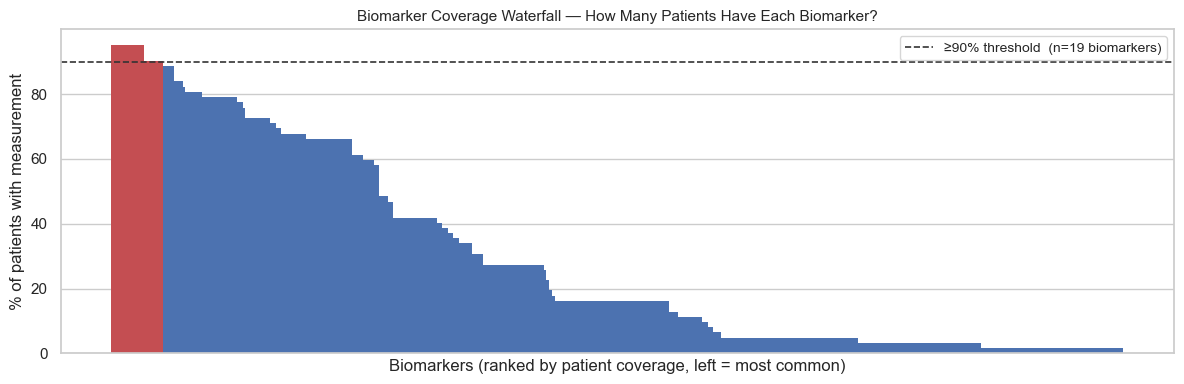


Blue bars: 351 biomarkers below threshold
Red bars : 19 biomarkers in the standard-of-care panel (≥90%)


In [10]:
# ── 5c. SoC panel table — grouped by organ ────────────────────────────────────
print(f"{'='*72}")
print(f"  STANDARD-OF-CARE PANEL  ({len(soc_panel)} biomarkers measured in ≥{THRESHOLD}% of patients)")
print(f"{'='*72}")

for organ, grp in (soc_panel.sort_values(["organ","pct_patients"], ascending=[True, False])
                             .groupby("organ", sort=False)):
    print(f"\n  ▸ {organ}")
    print(f"    {'Biomarker':<42} {'Source':<18} {'% Patients':>10}")
    print(f"    {'-'*42} {'-'*18} {'-'*10}")
    for _, row in grp.iterrows():
        print(f"    {row['biomarker_name']:<42} {row['source']:<18} {row['pct_patients']:>9.1f}%")

print(f"\n{'='*72}")

# ── 5d. Coverage waterfall: all biomarkers sorted by % coverage ───────────────
bio_all = bio_coverage_dedup.sort_values("pct_patients", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 4))
colors_all = ["#C44E52" if p >= THRESHOLD else "#4C72B0" for p in bio_all["pct_patients"]]
ax.bar(bio_all.index, bio_all["pct_patients"], color=colors_all,
       edgecolor="none", width=1.0)
ax.axhline(THRESHOLD, color="#333", linestyle="--", linewidth=1.2,
           label=f"≥{THRESHOLD}% threshold  (n={len(soc_panel)} biomarkers)")
ax.set_xlabel("Biomarkers (ranked by patient coverage, left = most common)")
ax.set_ylabel("% of patients with measurement")
ax.set_title("Biomarker Coverage Waterfall — How Many Patients Have Each Biomarker?",
             fontsize=11)
ax.legend(fontsize=10)
ax.set_xticks([])
plt.tight_layout()
plt.show()

print(f"\nBlue bars: {(bio_all['pct_patients'] < THRESHOLD).sum()} biomarkers below threshold")
print(f"Red bars : {len(soc_panel)} biomarkers in the standard-of-care panel (≥{THRESHOLD}%)")
